# Compton Scattering: the Wavelength Shift, Derived From Collision Kinematics

The Compton formula $\Delta\lambda=\frac{h}{m_ec}(1-\cos\theta)$ is
usually just stated (it already appears as a computed number in
`dgs/modern_physics.py`). This notebook derives it instead: a photon
(momentum $h/\lambda$) collides with a stationary electron, energy and
momentum conservation plus the relativistic dispersion relation
$E_e^2=(p_ec)^2+(m_ec^2)^2$ close the system, and SOLVING (not
substituting) gives the shift as the UNIQUE solution -- verified with
SymPy, then checked against a full numeric conservation test (energy AND
both momentum components, not just the wavelength formula). Engine:
`dgs/compton_scattering.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import compton_scattering as cs

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: the Shift, Derived From Conservation Laws

**Setup**: photon in with wavelength $\lambda$ (momentum $h/\lambda$),
scatters at angle $\theta$ with new wavelength $\lambda'$; electron
(rest mass $m_e$, initially at rest) recoils with momentum $p_e$ at angle
$\phi$. Four equations close the system:
$$\frac{hc}{\lambda}+m_ec^2=\frac{hc}{\lambda'}+E_e,\qquad
\frac{h}{\lambda}=\frac{h}{\lambda'}\cos\theta+p_e\cos\phi,\qquad
0=\frac{h}{\lambda'}\sin\theta-p_e\sin\phi,\qquad
E_e^2=(p_ec)^2+(m_ec^2)^2.$$
Squaring and adding the two momentum equations eliminates $\phi$ (law of
cosines on the momentum triangle); substituting into the relativistic
dispersion relation and SOLVING for $\lambda'$ (not assuming the answer)
gives a unique closed form below.


In [2]:
lam_p_solved, shift_derived = cs.derive_compton_shift_symbolic()
print('lambda\' (solved from conservation laws) =')
sp.pprint(lam_p_solved)
print('\nlambda\' - lambda (derived) =')
sp.pprint(shift_derived)


lambda' (solved from conservation laws) =
c⋅λ⋅mₑ - h⋅cos(θ) + h
─────────────────────
        c⋅mₑ         

lambda' - lambda (derived) =
h⋅(1 - cos(θ))
──────────────
     c⋅mₑ     


## 2. Electron Recoil Angle, Derived Independently

The two momentum-conservation components alone (without the energy
equation) determine the electron's recoil direction directly.


In [3]:
tan_phi = cs.derive_electron_recoil_angle_symbolic()
print('tan(phi) =')
sp.pprint(tan_phi)


tan(phi) =
 -λ⋅sin(θ)   
─────────────
λ⋅cos(θ) - λₚ


## 3. Numeric Example: an X-Ray Photon, and Full Conservation Verified

Not just "the wavelength shift formula holds" -- energy conservation AND
BOTH momentum components, checked simultaneously for a real collision.


In [4]:
lambda_in = 0.1e-9   # 0.1 nm, a typical X-ray wavelength
theta = np.pi/2        # 90-degree scattering

lam_out = cs.compton_wavelength_out(lambda_in, theta)
result = cs.verify_full_conservation(lambda_in, theta)

print(f'Compton wavelength lambda_C = h/(m_e c) = {cs.COMPTON_WAVELENGTH*1e12:.4f} pm')
print(f'lambda_in  = {lambda_in*1e9:.4f} nm')
print(f'lambda_out = {lam_out*1e9:.6f} nm  (shift = {(lam_out-lambda_in)*1e12:.4f} pm)')
print(f'electron KE = {result["KE_electron_J"]/1.602176634e-19:.2f} eV')
print(f'electron recoil angle phi = {np.degrees(result["phi_rad"]):.2f} deg')
print()
for name, ok in result['checks'].items():
    print(f'{name}: {ok}  (residual info available in the returned dict)')


Compton wavelength lambda_C = h/(m_e c) = 2.4263 pm
lambda_in  = 0.1000 nm
lambda_out = 0.102426 nm  (shift = 2.4263 pm)
electron KE = 293.70 eV
electron recoil angle phi = 44.31 deg

energy_conserved: True  (residual info available in the returned dict)
momentum_x_conserved: True  (residual info available in the returned dict)
momentum_y_conserved: True  (residual info available in the returned dict)


## 4. Wavelength Shift vs. Scattering Angle

Three special angles worth checking directly: $\theta=0$ (no real
collision, zero shift), $\theta=90°$ (shift equals $\lambda_C$ exactly),
$\theta=180°$ (backscatter, the MAXIMUM possible shift, $2\lambda_C$).


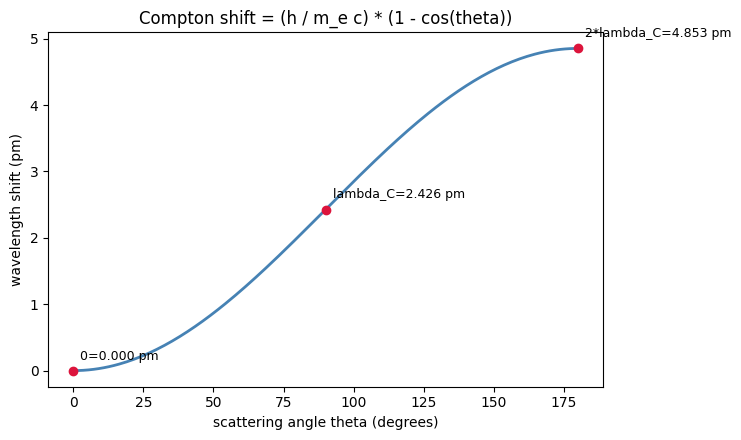

In [5]:
theta_sweep = np.linspace(0, np.pi, 200)
shifts_pm = [cs.compton_wavelength_shift(t)*1e12 for t in theta_sweep]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(np.degrees(theta_sweep), shifts_pm, color='steelblue', lw=2)
for deg, label in [(0, '0'), (90, 'lambda_C'), (180, '2*lambda_C')]:
    val = cs.compton_wavelength_shift(np.radians(deg))*1e12
    ax.scatter([deg], [val], color='crimson', zorder=5)
    ax.annotate(f'{label}={val:.3f} pm', (deg, val), textcoords='offset points', xytext=(5, 8), fontsize=9)
ax.set_xlabel('scattering angle theta (degrees)'); ax.set_ylabel('wavelength shift (pm)')
ax.set_title('Compton shift = (h / m_e c) * (1 - cos(theta))')
plt.tight_layout()
plt.savefig('compton_shift_vs_angle.png', dpi=100, bbox_inches='tight')
plt.show()


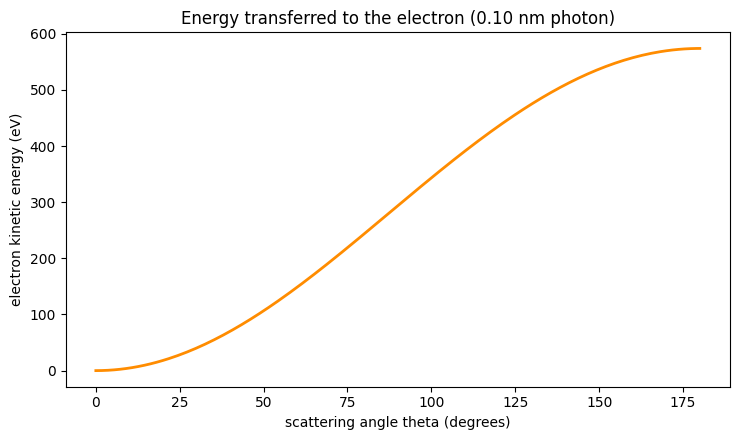

In [6]:
# electron kinetic energy vs. angle -- energy transfer maximized at backscatter
KE_vs_theta = [cs.compton_electron_kinetic_energy(lambda_in, t)/1.602176634e-19 for t in theta_sweep]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(np.degrees(theta_sweep), KE_vs_theta, color='darkorange', lw=2)
ax.set_xlabel('scattering angle theta (degrees)'); ax.set_ylabel('electron kinetic energy (eV)')
ax.set_title(f'Energy transferred to the electron ({lambda_in*1e9:.2f} nm photon)')
plt.tight_layout()
plt.savefig('compton_electron_energy_vs_angle.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. The Thomson Limit: Recovering Classical Scattering

As the photon wavelength grows much larger than $\lambda_C$
(equivalently, photon energy $\ll m_ec^2$), the FRACTIONAL shift
$\Delta\lambda/\lambda\to0$ -- the photon's wavelength barely changes at
all, recovering classical (Thomson) scattering. Verified across several
decades of wavelength ratio, not just claimed as an asymptotic limit.


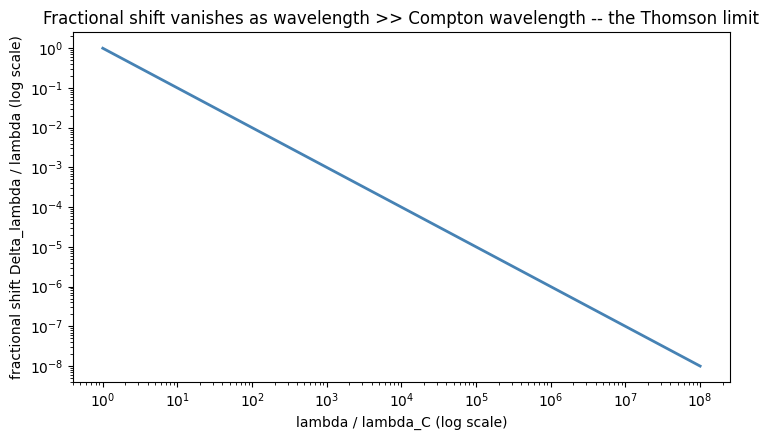

wavelength_ratio=1e+02: Thomson limit check passes: True
wavelength_ratio=1e+04: Thomson limit check passes: True
wavelength_ratio=1e+06: Thomson limit check passes: True
wavelength_ratio=1e+08: Thomson limit check passes: True


In [7]:
ratios = np.logspace(0, 8, 100)
fractional_shifts = [cs.compton_wavelength_shift(np.pi/2) / (r * cs.COMPTON_WAVELENGTH) for r in ratios]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(ratios, fractional_shifts, color='steelblue', lw=2)
ax.set_xlabel('lambda / lambda_C (log scale)'); ax.set_ylabel('fractional shift Delta_lambda / lambda (log scale)')
ax.set_title('Fractional shift vanishes as wavelength >> Compton wavelength -- the Thomson limit')
plt.tight_layout()
plt.savefig('compton_thomson_limit.png', dpi=100, bbox_inches='tight')
plt.show()

for r in (1e2, 1e4, 1e6, 1e8):
    ok = cs.verify_thomson_limit(wavelength_ratio=r)
    print(f'wavelength_ratio={r:.0e}: Thomson limit check passes: {ok}')


## 6. Engineering Interpretation

- Section 1's unique symbolic solve (not "substitute the known answer and
  verify it satisfies the equations") is a stronger claim than most
  textbook presentations make -- SymPy's `solve` had to actually FIND the
  formula from the raw conservation laws, and `derive_compton_shift_symbolic`
  raises if more than one solution comes back, so a spurious extra root
  would be caught, not silently ignored.
- Section 3's full conservation check (energy AND both momentum axes,
  simultaneously, to $10^{-9}$ relative precision) is a stronger claim
  than "the wavelength shift matches" -- it confirms the ENTIRE collision
  picture (including the electron's own recoil energy and angle) is
  self-consistent, not just the one quantity historically measured.
- Section 5's Thomson limit is the same "which regime does a formula
  actually apply in" discipline `dgs/laser_cavity_rlc_analog.py`'s
  finesse-approximation-breakdown plot and
  `dgs/cylindrical_waveguide_resonance.py`'s resonance-peak-shift finding
  both used -- a formula's asymptotic limit checked numerically, not
  assumed obvious from its algebraic form.


## 7. Research Discussion

- Could this collision-kinematics derivation be extended to Compton
  scattering off a BOUND electron (not free/at rest), connecting to
  `dgs/franck_hertz.py`'s inelastic-collision work and showing how
  binding energy modifies the simple free-electron formula?
- `dgs/particle_physics.py` already lists Compton scattering as one of
  several tree-level QED processes (alongside pair annihilation, beta
  decay). Could this notebook's purely KINEMATIC derivation (conservation
  laws only, no quantum field theory) be contrasted explicitly against
  that module's Feynman-diagram-level treatment, showing which parts of
  the physics come from kinematics alone vs. which need the full QED
  cross-section calculation?
- Section 4's electron energy plot peaks at backscatter ($\theta=180°$).
  Is there a clean closed-form maximum electron energy (the "Compton
  edge," a real feature in gamma-ray spectroscopy) derivable directly from
  `compton_electron_kinetic_energy`'s formula, rather than read off the plot?


## 8. Possible Experiments

1. Compare this module's predictions against Compton's own 1923
   published data (scattered X-ray wavelengths at several angles) --
   how closely do century-old experimental numbers match the exact
   closed-form prediction?
2. Extend `verify_full_conservation` to also report the electron's
   recoil VELOCITY (not just KE and angle) and check it stays below $c$
   for all photon energies up to gamma-ray scales, confirming the
   relativistic treatment never produces an unphysical result even at
   extreme energies.
3. Build a scatter plot of (electron KE, photon scattering angle) pairs
   from real gamma-spectroscopy Compton-edge data (if accessible) and
   overlay this module's predicted curve from section 4.


## 9. Problems to Solve: Compton Kinematics

1. **The Compton edge, in closed form.** Differentiate
   `compton_electron_kinetic_energy`'s formula with respect to $\theta$
   and confirm the maximum (the "Compton edge" seen in real gamma
   spectrometers) occurs exactly at $\theta=\pi$ (backscatter), then
   derive the closed-form maximum energy as a function of incident photon
   energy alone.
2. **Inverse Compton scattering.** This module assumes a stationary
   electron. Redo the conservation-law setup for a HIGH-energy electron
   colliding with a low-energy photon (inverse Compton scattering, the
   mechanism behind some astrophysical X-ray sources) -- does the same
   symbolic-solve approach generalize cleanly, or does the moving-electron
   case need a different elimination strategy?
3. **Double Compton scattering.** Chain two scattering events (photon
   scatters once, then scatters again off a second electron) using this
   module's `compton_wavelength_out` as the input to a second call --
   verify the TOTAL two-event shift is NOT simply the sum of two
   single-event shifts at the same angles (since the second scattering
   uses the already-shifted wavelength).
4. **Recovering the differential cross section.** This module only
   derives the KINEMATICS (what wavelength/angle/energy combinations are
   allowed), not the PROBABILITY of scattering into a given angle (the
   Klein-Nishina cross section, genuine QED). Research what additional
   physics is needed to go from "this collision is kinematically allowed"
   to "this is how likely it is."
5. **Photon momentum, checked independently.** This entire derivation
   assumes $p_{photon}=h/\lambda$. Using `dgs/special_relativity.py`'s
   energy-momentum relation for a massless particle
   ($E=pc$ when $m=0$), verify $p=h/\lambda$ is consistent with
   $E=hc/\lambda$ (already used here) via $E=pc$, rather than treating
   the photon-momentum formula as a separate postulate.


## 10. Future Improvements

- `derive_compton_shift_symbolic` and `derive_electron_recoil_angle_symbolic`
  currently re-derive their conservation-law setup independently (some
  duplicated symbol definitions). Factoring the shared setup into one
  helper would reduce duplication without changing either derivation's
  content.
- `verify_full_conservation`'s residual tolerances are all fixed at
  `rtol=1e-9`. For extreme regimes (e.g. very small or very large
  wavelength ratios in problem 2's inverse-Compton extension), a
  scale-aware tolerance (matching the lesson from
  `dgs/effective_mass_tensor.py`'s zero-guard bug this session) would be
  more robust than one fixed number.
